# PageRank on Graphs with Structural Irregularities

This section presents a computational analysis of the PageRank algorithm on a directed graph containing structural anomalies. The goal is to illustrate how deviations from ideal Markov chain assumptions affect the stationary distribution.

---

## Graph Structure

The graph consists of:

- A directed cycle:
  
  $$
  0 \to 1 \to 2 \to 0
  $$
  
  which forms a **rank sink (closed communicating class)**

- A bridge edge:
  
  $$
  2 \to 3
  $$

- A dangling node:
  
  $$
  3 \to 4, \quad d_4 = 0
  $$

---

## Transition Matrix Construction

Let $P \in \mathbb{R}^{n \times n}$ denote the row-stochastic transition matrix:

$$
P_{ij} = \frac{A_{ij}}{d_i}
$$

where:
- $A$ is the adjacency matrix  
- $d_i$ is the out-degree of node $i$

For node $4$, we have:

$$
d_4 = 0 \Rightarrow \sum_j P_{4j} = 0
$$

Thus, $P$ is no longer stochastic, leading to **loss of probability mass**.

---

## PageRank Formulation

The PageRank vector $\pi$ satisfies:

$$
\pi = \alpha P^T \pi + (1 - \alpha)\frac{1}{n}\mathbf{1}
$$

where $\alpha = 0.85$ is the damping factor.

This ensures:
- irreducibility  
- aperiodicity  
- existence of a unique stationary distribution  

---

## Visualization Interpretation

The graph visualization encodes:

- Node size $\propto \pi_i$  
- Node color $\propto \pi_i$  

### Observations

- Nodes $\{0,1,2\}$ retain high probability mass due to cyclic structure  
- Node $4$ receives minimal importance due to lack of outgoing links  
- The bridge node $3$ transfers probability but does not retain it  

This demonstrates how **graph topology directly influences stationary distributions**.

C:\Users\arush\AppData\Local\Temp\ipykernel_3312\4243206708.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=cm.get_cmap('viridis'),


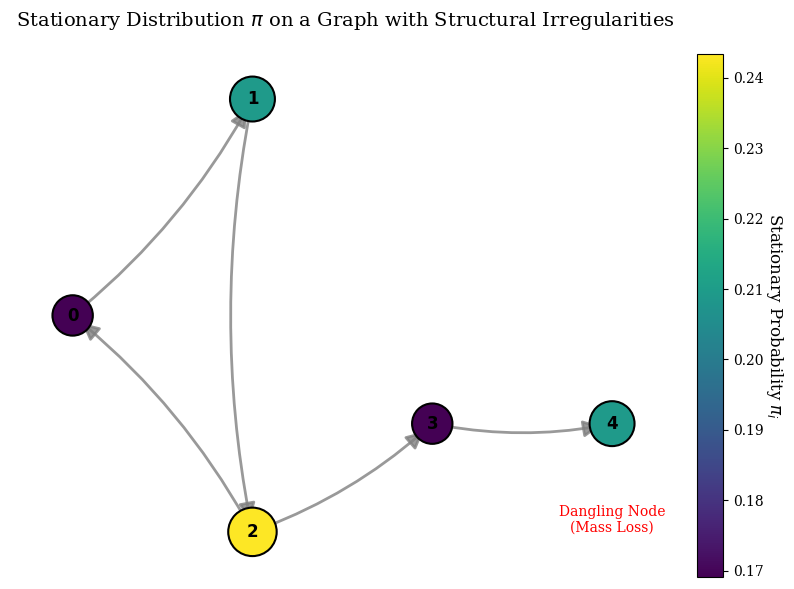

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.linalg import eig

plt.rcParams.update({
    "text.usetex": False, 
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

def academic_pagerank_analysis():
    # 1. Graph Construction (As defined in LaTeX Section 3)
    # 0->1->2->0 (Cycle/Rank Sink), 2->3 (Bridge), 3->4 (Dangling)
    G = nx.DiGraph()
    edges = [(0, 1), (1, 2), (2, 0), (2, 3), (3, 4)]
    G.add_edges_from(edges)
    
    # 2. Mathematical Extraction
    # P represents the row-stochastic transition matrix
    # Note: Row 4 will be all zeros, illustrating the "Dangling Node" limitation
    nodes = sorted(G.nodes())
    P = nx.to_numpy_array(G, nodelist=nodes)
    # Normalize rows to be stochastic where possible
    row_sums = P.sum(axis=1)
    # Avoid division by zero for dangling nodes
    P_stoch = np.divide(P, row_sums[:, np.newaxis], 
                        out=np.zeros_like(P), 
                        where=row_sums[:, np.newaxis]!=0)

    # 3. PageRank Computation (Power Iteration approximation)
    alpha = 0.85
    pr = nx.pagerank(G, alpha=alpha)
    
    # 4. Visualization Setup
    fig, ax = plt.subplots(figsize=(8, 6))
    pos = {
        0: (0, 1), 1: (1, 1.5), 2: (1, 0.5), # The Sink Cluster
        3: (2, 0.75),                        # The Bridge
        4: (3, 0.75)                         # The Dangling Node
    }

    # Map PR values to aesthetics
    node_list = list(G.nodes())
    pr_values = np.array([pr[n] for n in node_list])
    
    # Normalize sizes for clarity (scaling pi_i)
    node_sizes = 5000 * pr_values 
    node_colors = pr_values

    # 5. Drawing the Markov Chain
    nodes_draw = nx.draw_networkx_nodes(
        G, pos, 
        node_size=node_sizes, 
        node_color=node_colors,
        cmap=cm.get_cmap('viridis'),
        edgecolors='black',
        linewidths=1.5,
        ax=ax
    )
    
    nx.draw_networkx_edges(
        G, pos, 
        width=2, 
        arrowsize=25, 
        connectionstyle='arc3,rad=0.1',
        edge_color='gray',
        alpha=0.8,
        ax=ax
    )
    
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

    # 6. Metadata and Annotations
    plt.title(r" Stationary Distribution $\pi$ on a Graph with Structural Irregularities", pad=20)
    
    cbar = plt.colorbar(nodes_draw, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'Stationary Probability $\pi_i$', rotation=270, labelpad=15)
    
    ax.text(3.0, 0.5, "Dangling Node\n(Mass Loss)", fontsize=10, color='red', ha='center')

    plt.axis('off')
    plt.tight_layout()
    plt.savefig("pagerank_academic_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    academic_pagerank_analysis()

# Reducibility in Markov Chains

A Markov chain is said to be **reducible** if its state space can be partitioned into disjoint subsets such that transitions between subsets are not possible.

---

## Graph Structure

We construct a graph consisting of two disjoint strongly connected components:

$$
\mathcal{C}_1 = \{0,1,2\}, \quad
\mathcal{C}_2 = \{3,4,5\}
$$

Each component forms a closed communicating class.

---

## Consequences of Reducibility

The transition matrix $P^T$ can be permuted into block diagonal form:

$$
P^T =
\begin{bmatrix}
P_1 & 0 \\
0 & P_2
\end{bmatrix}
$$

This implies:

- Multiple invariant subspaces exist  
- The eigenvalue $\lambda = 1$ has multiplicity greater than one  
- The stationary distribution is **not unique**

---

## Interpretation

Each component admits its own stationary distribution. Any convex combination:

$$
\pi = \alpha \pi^{(1)} + (1 - \alpha)\pi^{(2)}
$$

is also a valid stationary distribution.

The visualization highlights this decomposition by separating the graph into two independent substructures.

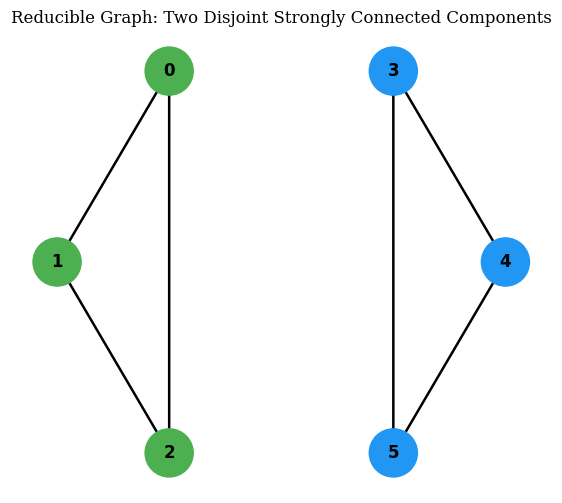

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Component 1 (Invariant subspace 1)
G.add_edges_from([(0,1),(1,2),(2,0)])

# Component 2 (Invariant subspace 2)
G.add_edges_from([(3,4),(4,5),(5,3)])

pos = {
    0: (-1, 1),
    1: (-2, 0),
    2: (-1, -1),

    3: (1, 1),
    4: (2, 0),
    5: (1, -1)
}

# Colors for components
colors = ['#4CAF50']*3 + ['#2196F3']*3

plt.figure(figsize=(7,6))

nx.draw_networkx_nodes(G, pos,
                       node_color=colors,
                       node_size=1200)

nx.draw_networkx_edges(G, pos,
                       arrows=True,
                       arrowstyle='->',
                       width=1.8)

nx.draw_networkx_labels(G, pos,
                       font_size=12,
                       font_weight='bold')

plt.title("Reducible Graph: Two Disjoint Strongly Connected Components", fontsize=12)
plt.axis('off')

plt.savefig("reducible_clean.png", dpi=300, bbox_inches='tight')
plt.show()

# Spectral Analysis of Reducibility

To formally analyze reducibility, we study the eigenstructure of the transition matrix.

---

## Matrix Representation

Let $M = P^T$ denote the column-stochastic transition matrix.

For a reducible graph:

$$
M =
\begin{bmatrix}
P_1 & 0 \\
0 & P_2
\end{bmatrix}
$$



## Eigenvalue Structure

For stochastic matrices:

- $\lambda = 1$ is always an eigenvalue  
- In reducible cases, its multiplicity exceeds one  

$$
\dim E(1) > 1
$$



## Stationary Distributions

Each invariant subspace contributes one basis vector:

$$
\mathbf{v}_1 =
\begin{bmatrix}
\pi^{(1)} \\
0
\end{bmatrix}, \quad
\mathbf{v}_2 =
\begin{bmatrix}
0 \\
\pi^{(2)}
\end{bmatrix}
$$

Thus, the general stationary distribution is:

$$
\pi = \alpha \mathbf{v}_1 + (1 - \alpha)\mathbf{v}_2
$$



## Visualization

The figure consists of:

### (a) Block Matrix Heatmap
- Displays the block diagonal structure of $P^T$  
- Highlights independent subspaces  

### (b) Eigenvector Basis Plot
- Shows multiple stationary distributions  
- Each basis vector corresponds to one component  



## Conclusion

The spectral analysis confirms that reducibility leads to:

- Non-unique stationary distributions  
- Multiple invariant subspaces  
- Failure of convergence guarantees without damping  

This motivates the use of the **Google matrix**, which enforces irreducibility.

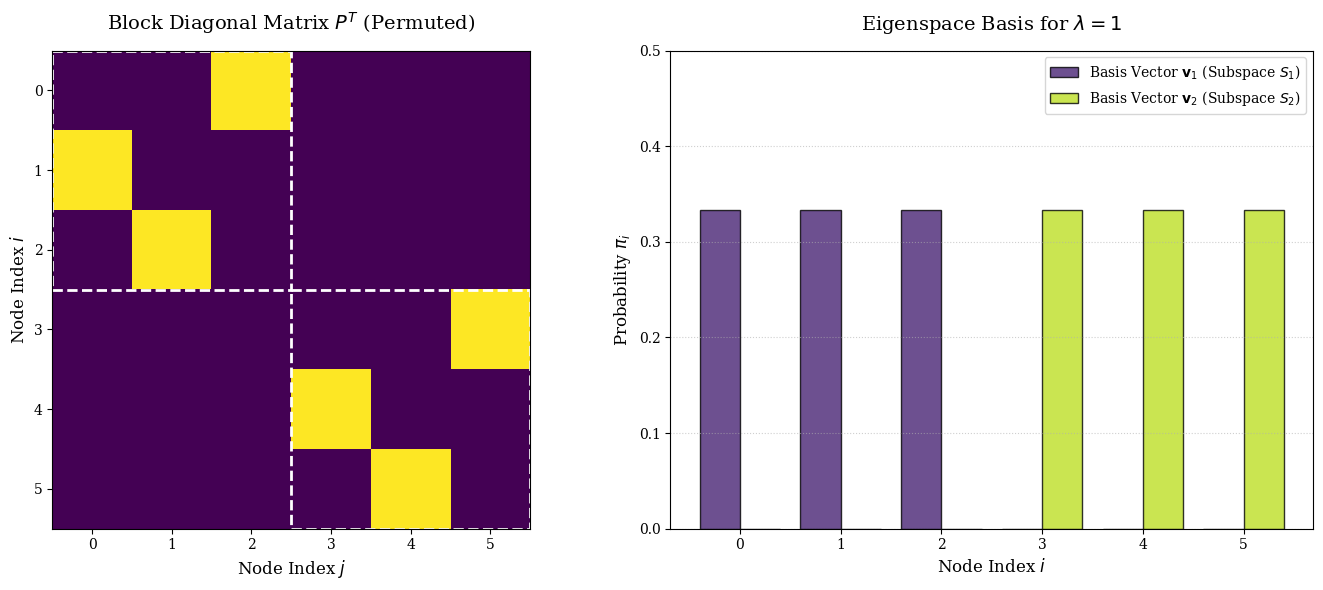

In [4]:


def rigorous_reducibility_spectral():
    """
    Analyzes spectral properties of a reducible Markov Chain.
    """
    # 1. Construct a Reducible Graph G = C1 U C2
    # Two disjoint cycles: {0,1,2} and {3,4,5}
    G = nx.DiGraph([(0,1), (1,2), (2,0), (3,4), (4,5), (5,3)])
    n = G.number_of_nodes()
    
    # 2. Derive Column-Stochastic Transition Matrix M = P^T
    A = nx.to_numpy_array(G).T 
    # Handle normalization (ensure no division by zero, though not present here)
    M = np.divide(A, A.sum(axis=0), out=np.zeros_like(A), where=A.sum(axis=0)!=0)
    
    # 3. Eigen-decomposition to find the basis of E(1)
    vals, vecs = eig(M)
    idx_lambda_1 = np.where(np.isclose(vals, 1.0))[0]
    basis_vectors = vecs[:, idx_lambda_1].real
    # Normalize basis vectors so they represent valid probability distributions
    basis_vectors = basis_vectors / basis_vectors.sum(axis=0)

    # 4. Visualization Setup 
    
    plt.rcParams.update({
        "text.usetex": False, 
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],
        "axes.titlesize": 14,
        "axes.labelsize": 12
    })
    fig = plt.figure(figsize=(14, 6))
    
    color_v1 = cm.viridis(0.1) 
    color_v2 = cm.viridis(0.9) 

    # Subplot 1: Matrix Heatmap 
    ax1 = fig.add_subplot(121)
    im = ax1.imshow(M, cmap='viridis', interpolation='none')
    ax1.set_title(r"Block Diagonal Matrix $P^T$ (Permuted)", fontsize=14, pad=15)
    
    # the blocks P1 and P2 with contrasting lines
    ax1.add_patch(plt.Rectangle((-.5, -.5), 3, 3, fill=False, edgecolor='white', lw=2, linestyle='--'))
    ax1.add_patch(plt.Rectangle((2.5, 2.5), 3, 3, fill=False, edgecolor='white', lw=2, linestyle='--'))
    
    ax1.set_xticks(range(n)); ax1.set_yticks(range(n))
    ax1.set_xlabel("Node Index $j$"); ax1.set_ylabel("Node Index $i$")

    # Subplot 2: Eigenspace Basis (Stationary Distributions)
    ax2 = fig.add_subplot(122)
    x_axis = np.arange(n)
    
    ax2.bar(x_axis - 0.2, basis_vectors[:, 0], width=0.4, 
            label=r"Basis Vector $\mathbf{v}_1$ (Subspace $S_1$)", color=color_v1, edgecolor='black', alpha=0.8)
    ax2.bar(x_axis + 0.2, basis_vectors[:, 1], width=0.4, 
            label=r"Basis Vector $\mathbf{v}_2$ (Subspace $S_2$)", color=color_v2, edgecolor='black', alpha=0.8)
    
    ax2.set_title(r"Eigenspace Basis for $\lambda=1$", fontsize=14, pad=15)
    ax2.set_xlabel("Node Index $i$")
    ax2.set_ylabel(r"Probability $\pi_i$")
    ax2.set_xticks(range(n))
    ax2.set_ylim(0, 0.5) 
    ax2.legend(frameon=True, loc='upper right')
    ax2.grid(axis='y', linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.savefig("reducibility_spectral.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    rigorous_reducibility_spectral()

---